In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

In [3]:
df = pd.read_csv('diabetes.csv')
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [16]:
shapiro_test= stats.shapiro(df['Glucose'])
print("Shapiro-Wilk p-value:",shapiro_test.pvalue)


Shapiro-Wilk p-value: 1.9863474999979633e-11


In [5]:
if shapiro_test.pvalue <0.05:
    print("Data IS NOT normally distributed")
else:
    print("Data IS normally distributed")
    

Data IS NOT normally distributed


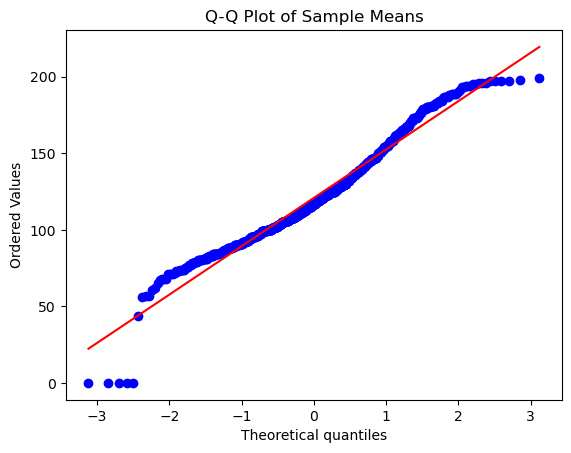

In [6]:
#Generate a Q-Q plot for the sample means 
stats.probplot(df['Glucose'],dist="norm",plot=plt)
plt.title('Q-Q Plot of Sample Means')
plt.show()

In [7]:
#Central Limit Theorem
sample_means=[]
n_samples = 100
sample_size = 30

In [9]:
for _ in range(n_samples):
    sample= df['Glucose'].sample(n=sample_size,replace=True)
    sample_means.append(sample.mean())

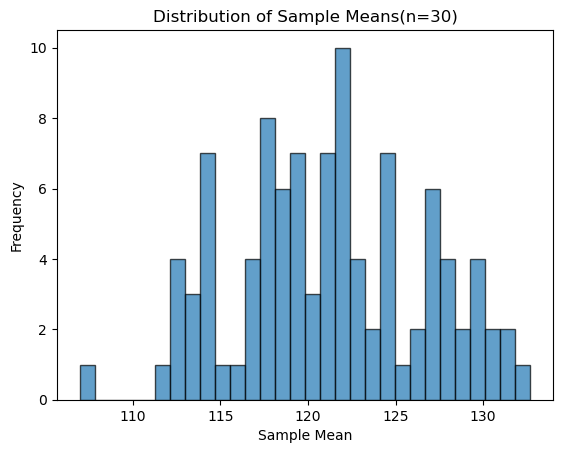

In [10]:
#PLot the distribution of sample means
plt.hist(sample_means,bins=30,edgecolor='k',alpha=0.7)
plt.title('Distribution of Sample Means(n=30)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.show()

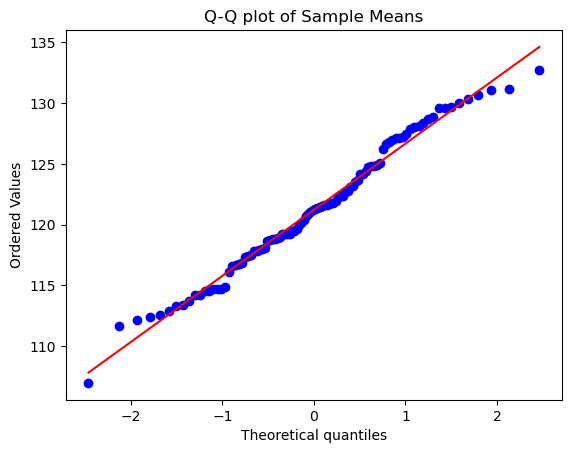

In [11]:
#Generate a Q-Q plot for the sample means 
stats.probplot(sample_means, dist="norm",plot=plt)
plt.title('Q-Q plot of Sample Means')
plt.show()


In [13]:
#Perform the Shapiro-Wilk test on the sample means
shapiro_test = stats.shapiro(sample_means)
print("Shapiro-Wilk p-value:",shapiro_test.pvalue)

Shapiro-Wilk p-value: 0.3165720757406425


In [15]:
#Interpret the result
if shapiro_test.pvalue < 0.05:
    print("The data likely does not follow a normal distribution")
else:
    print("The data may be normally distributed, but the  q-q plot can provide further insights.")


The data may be normally distributed, but the  q-q plot can provide further insights.
